In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.metrics import accuracy_score,mean_absolute_error,classification_report
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("NYC_Taxi_Cleaned_Analysis_Ready.csv")
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,duration_min,speed_mph,pickup_hour,day_of_week,is_weekend
0,2,2025-01-18 20:53:30,2025-01-18 21:00:47,1,0.97,1,N,238,166,1,...,1.0,13.32,0.0,0.00,0.00,7.283333,7.990847,20,Saturday,True
1,1,2025-01-25 11:12:51,2025-01-25 11:17:57,1,0.60,1,N,50,48,2,...,1.0,10.55,2.5,0.00,0.75,5.100000,7.058824,11,Saturday,True
2,1,2025-01-21 15:09:31,2025-01-21 15:19:02,1,0.80,1,N,236,237,1,...,1.0,16.65,2.5,0.00,0.00,9.516667,5.043783,15,Tuesday,False
3,2,2025-01-11 22:25:45,2025-01-11 22:34:22,2,1.93,1,N,231,68,1,...,1.0,20.37,2.5,0.00,0.75,8.616667,13.439072,22,Saturday,True
4,2,2025-01-04 23:37:07,2025-01-04 23:45:58,1,4.44,1,N,137,88,0,...,1.0,35.12,0.0,NaN,0.00,8.850000,30.101695,23,Saturday,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3946693,2,2025-11-12 22:43:32,2025-11-12 23:14:50,2,17.06,1,N,132,123,3,...,1.0,72.75,2.5,1.75,0.00,31.300000,32.702875,22,Wednesday,False
3946694,2,2025-11-03 10:04:04,2025-11-03 10:12:17,2,1.36,1,N,41,166,1,...,1.0,11.50,0.0,0.00,0.00,8.216667,9.931034,10,Monday,False
3946695,1,2025-11-17 22:52:30,2025-11-17 23:05:40,1,1.70,1,N,249,170,1,...,1.0,23.10,2.5,0.00,0.75,13.166667,7.746835,22,Monday,False
3946696,2,2025-11-02 00:34:54,2025-11-02 00:36:16,1,0.19,1,N,75,263,0,...,1.0,36.49,0.0,NaN,0.00,1.366667,8.341463,0,Sunday,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3946698 entries, 0 to 3946697
Data columns (total 25 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        int64  
 4   trip_distance          float64
 5   RatecodeID             int64  
 6   store_and_fwd_flag     object 
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           int64  
 10  fare_amount            float64
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             float64
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           float64
 17  congestion_surcharge   float64
 18  Airport_fee            float64
 19  cbd_congestion_fee     float64
 20  duration_min           float64
 21  speed_mph              float64
 22  pickup_hour       

## data preprocessing

In [4]:
#check null value
df.isna().sum()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count               0
trip_distance                 0
RatecodeID                    0
store_and_fwd_flag            0
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge          0
Airport_fee              757387
cbd_congestion_fee            0
duration_min                  0
speed_mph                     0
pickup_hour                   0
day_of_week                   0
is_weekend                    0
dtype: int64

In [5]:
df['Airport_fee']= df['Airport_fee'].fillna(0)

In [6]:
#recheck null value
df.isna().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
Airport_fee              0
cbd_congestion_fee       0
duration_min             0
speed_mph                0
pickup_hour              0
day_of_week              0
is_weekend               0
dtype: int64

In [7]:
# check duplicate
duplicates = df[df.duplicated(
    subset=['tpep_pickup_datetime','tpep_dropoff_datetime','total_amount'],
    keep=False
)].sort_values(['total_amount'])
print(duplicates)

         VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
1653628         2  2025-05-07 12:16:05   2025-05-07 12:21:41                1   
1626518         2  2025-05-07 12:16:05   2025-05-07 12:21:41                1   
3151382         2  2025-09-03 19:55:54   2025-09-03 20:01:10                1   
2955843         1  2025-09-03 19:55:54   2025-09-03 20:01:10                1   
422211          2  2025-02-23 12:56:54   2025-02-23 13:02:23                2   
545177          2  2025-02-23 12:56:54   2025-02-23 13:02:23                1   
3818291         2  2025-11-18 09:45:15   2025-11-18 09:53:48                1   
3755587         2  2025-11-18 09:45:15   2025-11-18 09:53:48                1   
1100906         2  2025-04-11 20:27:40   2025-04-11 20:35:44                1   
1071046         2  2025-04-11 20:27:40   2025-04-11 20:35:44                1   
655311          2  2025-03-07 23:59:40   2025-03-08 00:07:38                1   
721286          2  2025-03-0

In [8]:
print(
    duplicates.groupby(
        ['tpep_pickup_datetime', 'tpep_dropoff_datetime','total_amount']
    ).nunique()
)

                                                         VendorID  \
tpep_pickup_datetime tpep_dropoff_datetime total_amount             
2025-02-23 12:56:54  2025-02-23 13:02:23   15.18                1   
2025-03-04 09:58:00  2025-03-04 10:17:25   27.78                1   
2025-03-07 23:59:40  2025-03-08 00:07:38   18.06                1   
2025-04-11 20:27:40  2025-04-11 20:35:44   18.00                1   
2025-05-07 12:16:05  2025-05-07 12:21:41   11.90                1   
2025-09-03 19:55:54  2025-09-03 20:01:10   14.75                2   
2025-11-18 09:45:15  2025-11-18 09:53:48   15.45                1   

                                                         passenger_count  \
tpep_pickup_datetime tpep_dropoff_datetime total_amount                    
2025-02-23 12:56:54  2025-02-23 13:02:23   15.18                       2   
2025-03-04 09:58:00  2025-03-04 10:17:25   27.78                       2   
2025-03-07 23:59:40  2025-03-08 00:07:38   18.06                       2  

In [9]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
df['is_weekend'] = df['is_weekend'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3946698 entries, 0 to 3946697
Data columns (total 25 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  datetime64[ns]
 3   passenger_count        int64         
 4   trip_distance          float64       
 5   RatecodeID             int64         
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

## EDA

In [10]:
trips_by_hours = df.groupby("pickup_hour").size()
total_revenue = df.groupby("pickup_hour")['total_amount'].sum()

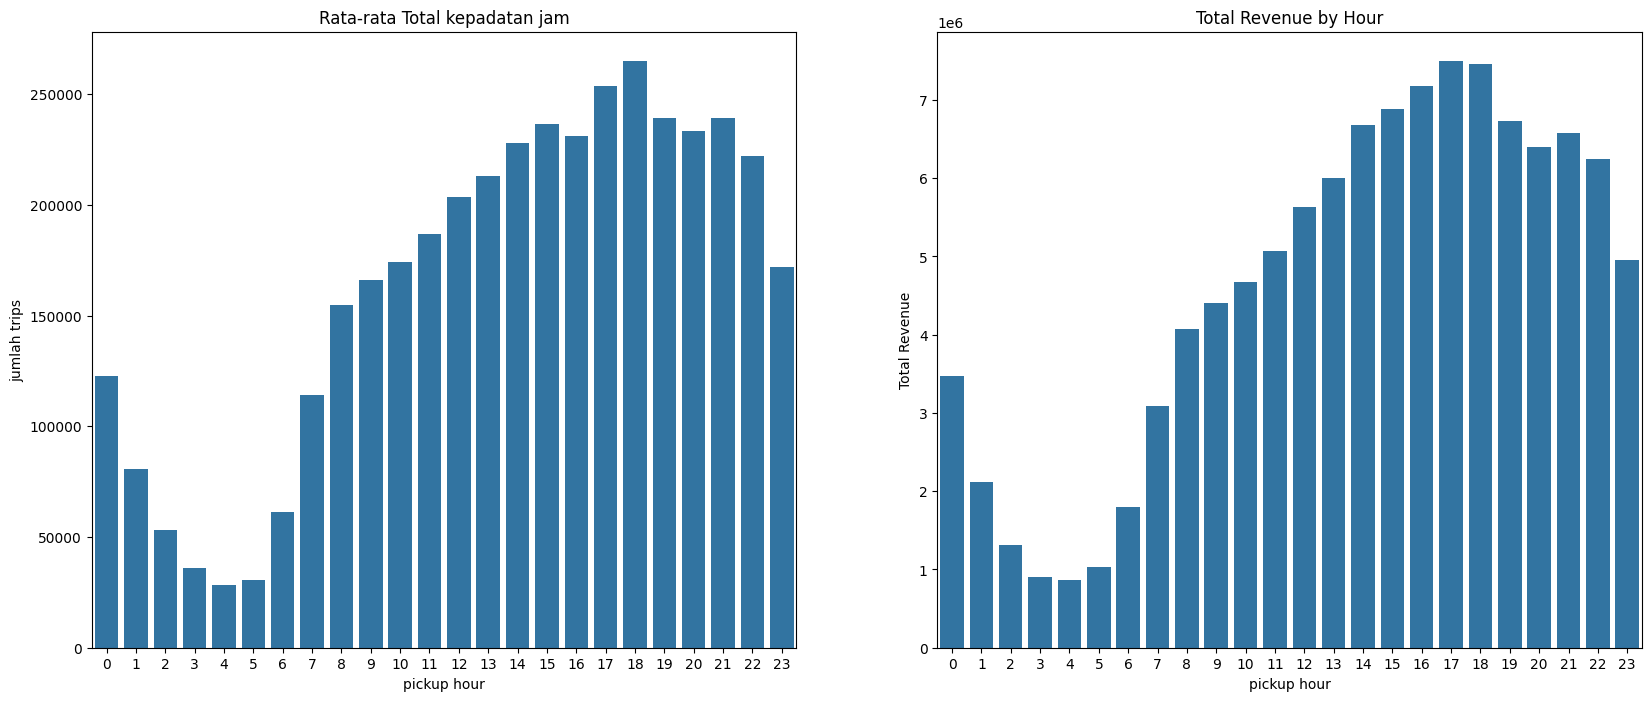

In [11]:

fig, ax = plt.subplots(1,2,figsize=(20, 8))
sns.barplot(data=trips_by_hours,ax=ax[0])
ax[0].set_xlabel("pickup hour")
ax[0].set_ylabel("jumlah trips")
ax[0].set_title('Rata-rata Total kepadatan jam')

sns.barplot(data=total_revenue,ax=ax[1])
ax[1].set_xlabel("pickup hour")
ax[1].set_ylabel("Total Revenue")
ax[1].set_title('Total Revenue by Hour')

plt.show()


In [12]:
# Hitung total revenue per jam
total_revenue = df.groupby("pickup_hour")['total_amount'].sum()
# Dapatkan jam dengan revenue tertinggi
jam_tertinggi = total_revenue.idxmax()
# Dapatkan nilai nominal revenue tertinggi
nilai_tertinggi = total_revenue.max()
print(f"Jam dengan total revenue tertinggi adalah jam {jam_tertinggi} dengan total pendapatan sebesar: ${nilai_tertinggi:,.2f}")

Jam dengan total revenue tertinggi adalah jam 17 dengan total pendapatan sebesar: $7,497,795.88


### Insight
1. Kepadatan terjadi saat mulai jam 8 pagi hingga jam 5 - 6 sore dimana bisa mendapatkan total pendapatan $7,497,795.88

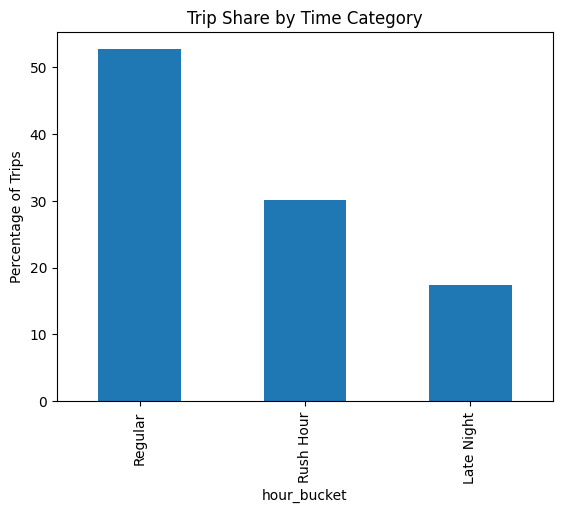

In [13]:
def hour_bucket(h):
    if (7 <= h <= 9) or (16 <= h <= 18):
        return "Rush Hour"
    elif h in [22,23,0,1,2,3]:
        return "Late Night"
    else:
        return "Regular"

df["hour_bucket"] = df["pickup_hour"].apply(hour_bucket)

bucket_counts = df["hour_bucket"].value_counts(normalize=True) * 100

plt.figure()
bucket_counts.plot(kind="bar")
plt.title("Trip Share by Time Category")
plt.ylabel("Percentage of Trips")
plt.show()

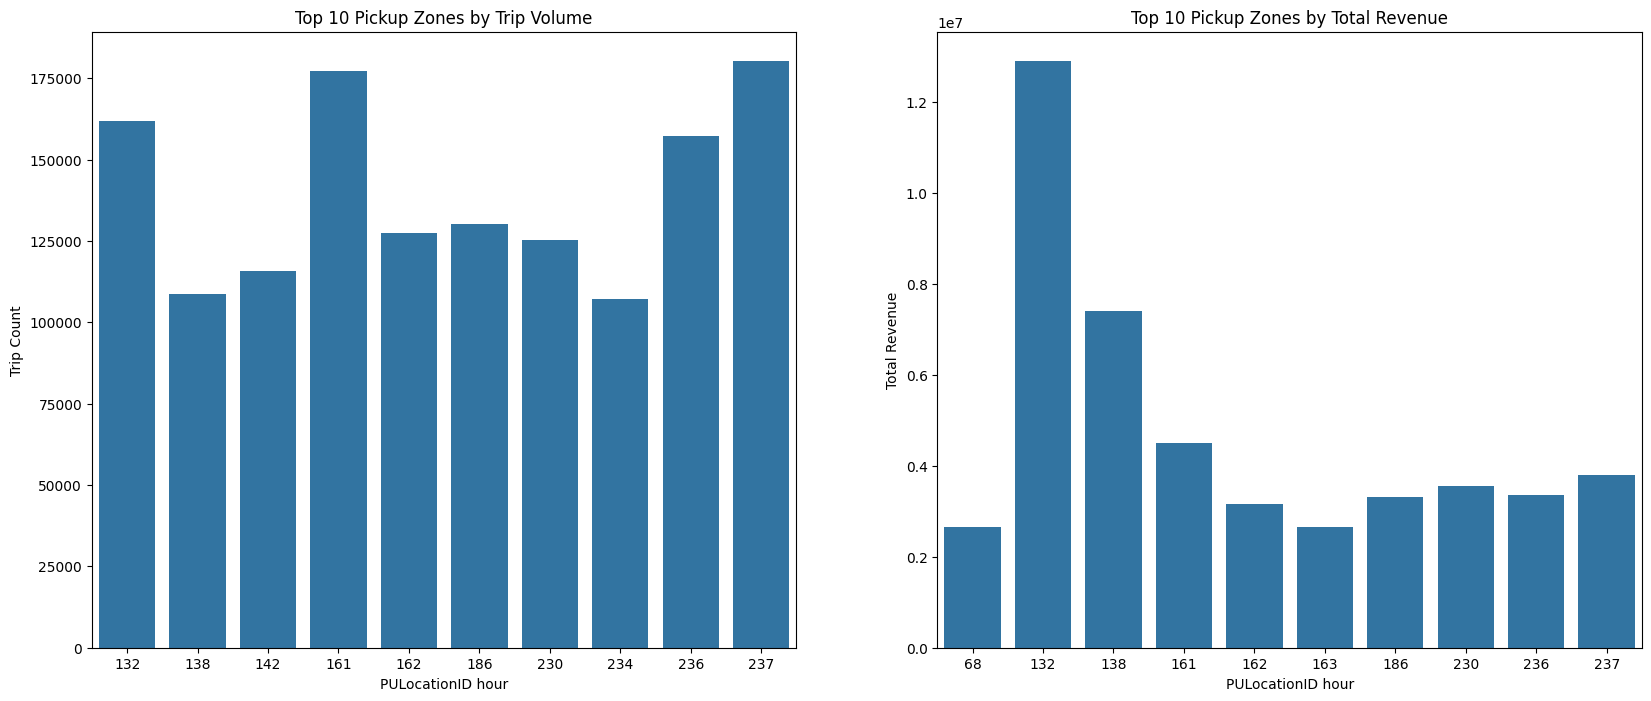

In [14]:
zone_volume = df.groupby("PULocationID").size().sort_values(ascending=False).head(10)
zone_revenue = df.groupby("PULocationID")["total_amount"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(1,2,figsize=(20, 8))
sns.barplot(data=zone_volume,ax=ax[0])
ax[0].set_xlabel("PULocationID hour")
ax[0].set_ylabel("Trip Count")
ax[0].set_title('Top 10 Pickup Zones by Trip Volume')

sns.barplot(data=zone_revenue,ax=ax[1])
ax[1].set_xlabel("PULocationID hour")
ax[1].set_ylabel("Total Revenue")
ax[1].set_title('Top 10 Pickup Zones by Total Revenue')



plt.show()


### Label Encoding

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['store_and_fwd_flag'] = le.fit_transform(df['store_and_fwd_flag'])

In [16]:
df['store_and_fwd_flag']

0          0
1          0
2          0
3          0
4          0
          ..
3946693    0
3946694    0
3946695    0
3946696    0
3946697    0
Name: store_and_fwd_flag, Length: 3946698, dtype: int64

In [17]:
#cek isi data kolom 
df['day_of_week'].value_counts()

day_of_week
Saturday     619101
Thursday     607734
Wednesday    585932
Friday       582910
Tuesday      541427
Sunday       534821
Monday       474773
Name: count, dtype: int64

In [18]:
#cek isi data kolom 
df['hour_bucket'].value_counts()

hour_bucket
Regular       2074401
Rush Hour     1185064
Late Night     687233
Name: count, dtype: int64

### One Hot Encoding

In [19]:
from numpy import dtype
df_encode = pd.get_dummies(df,
    columns=['day_of_week','hour_bucket'],drop_first=True, dtype=int
)
df_encode.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,pickup_hour,is_weekend,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,hour_bucket_Regular,hour_bucket_Rush Hour
0,2,2025-01-18 20:53:30,2025-01-18 21:00:47,1,0.97,1,0,238,166,1,...,20,1,0,1,0,0,0,0,1,0
1,1,2025-01-25 11:12:51,2025-01-25 11:17:57,1,0.60,1,0,50,48,2,...,11,1,0,1,0,0,0,0,1,0
2,1,2025-01-21 15:09:31,2025-01-21 15:19:02,1,0.80,1,0,236,237,1,...,15,0,0,0,0,0,1,0,1,0
3,2,2025-01-11 22:25:45,2025-01-11 22:34:22,2,1.93,1,0,231,68,1,...,22,1,0,1,0,0,0,0,0,0
4,2,2025-01-04 23:37:07,2025-01-04 23:45:58,1,4.44,1,0,137,88,0,...,23,1,0,1,0,0,0,0,0,0


### BoxPlot Cek Outlier

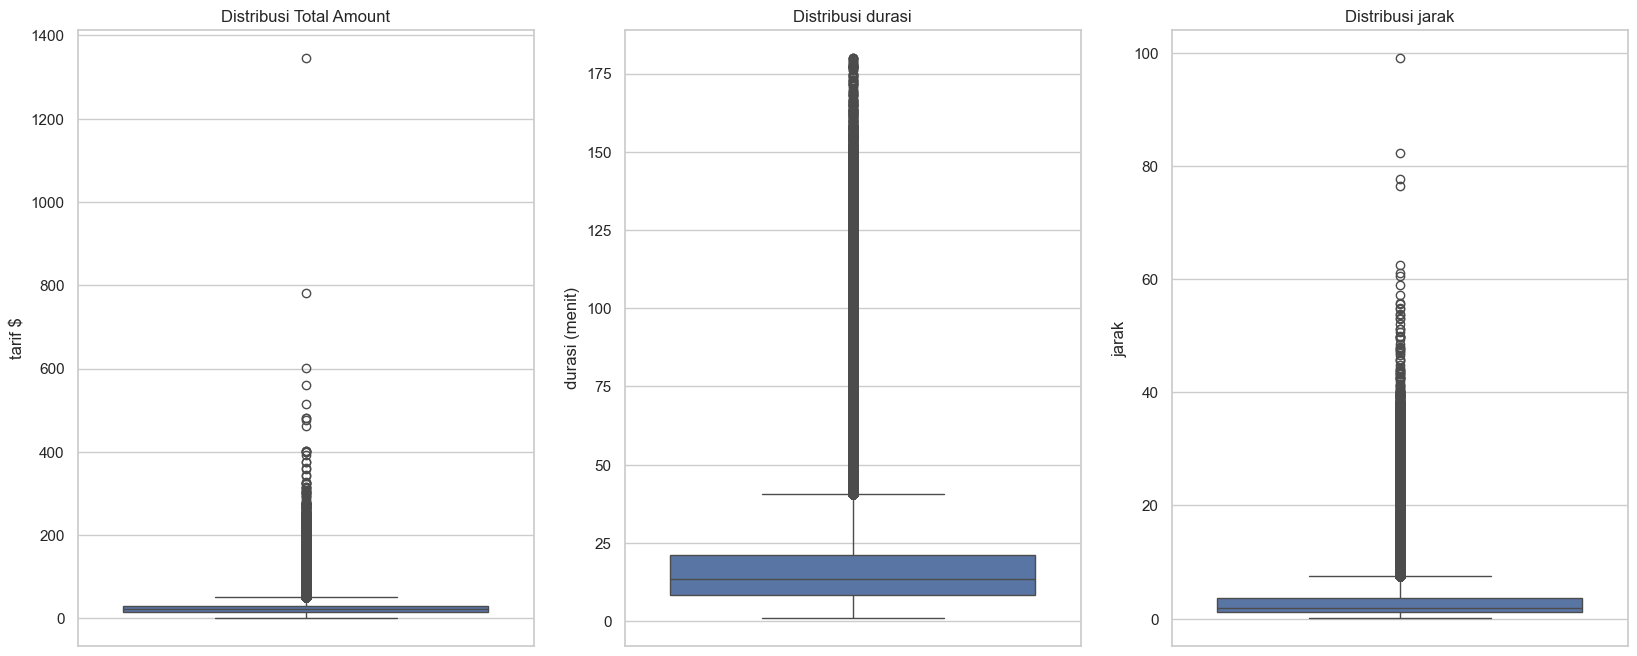

In [20]:
sns.set_theme(style='whitegrid')
fix,ax = plt.subplots(1,3,figsize=(20,8))

sns.boxplot(data=df_encode['total_amount'],ax=ax[0])
ax[0].set_ylabel("tarif $")
ax[0].set_title('Distribusi Total Amount')

sns.boxplot(data=df_encode['duration_min'],ax=ax[1])
ax[1].set_ylabel("durasi (menit)")
ax[1].set_title('Distribusi durasi')

sns.boxplot(data=df_encode['trip_distance'],ax=ax[2])
ax[2].set_ylabel("jarak")
ax[2].set_title('Distribusi jarak')

plt.show()

In [21]:
# melihat total pendapatan outlier
df_encode.loc[
    df_encode['total_amount'] > 1200,
    ['total_amount', 'trip_distance', 'duration_min']
]

,total_amount,trip_distance,duration_min
2971888,1345.71,4.0,22.683333


In [22]:
# membandingkannya dengan jarak yang sama
df_encode.loc[
    df_encode['trip_distance'] > 4,
    ['total_amount', 'trip_distance', 'duration_min']
]

,total_amount,trip_distance,duration_min
4,35.12,4.44,8.850000
10,38.16,5.16,22.350000
19,34.02,4.05,21.316667
22,38.00,31.20,50.300000
28,26.25,4.15,16.433333
...,...,...,...
3946667,36.05,6.03,16.366667
3946672,59.24,8.50,35.400000
3946689,25.45,5.02,9.250000
3946691,82.24,10.87,44.566667


In [23]:
print(df_encode['total_amount'].describe(percentiles=[0.95, 0.99]),df_encode['duration_min'].describe(percentiles=[0.95, 0.99]),df_encode['trip_distance'].describe(percentiles=[0.95, 0.99]))

count    3.946698e+06
mean     2.813628e+01
std      1.988695e+01
min      1.010000e+00
50%      2.186000e+01
95%      7.650000e+01
99%      1.016500e+02
max      1.345710e+03
Name: total_amount, dtype: float64 count    3.946698e+06
mean     1.697423e+01
std      1.339776e+01
min      1.000000e+00
50%      1.338333e+01
95%      4.300000e+01
99%      6.938333e+01
max      1.799667e+02
Name: duration_min, dtype: float64 count    3.946698e+06
mean     3.441244e+00
std      4.121952e+00
min      1.100000e-01
50%      1.900000e+00
95%      1.274000e+01
99%      1.927000e+01
max      9.906000e+01
Name: trip_distance, dtype: float64


## Feature Engineering

In [24]:
#Filter outlier menggunakan DataFrame baru (df_encoded)
df_clean = df_encode[
    (df_encode['total_amount'] > 0) & (df_encode['total_amount'] < 200) &
    (df_encode['duration_min'] > 0) & (df_encode['duration_min'] < 120) &
    (df_encode['trip_distance'] > 0) & (df_encode['trip_distance'] < 50)
]


In [25]:
df_clean.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,pickup_hour,is_weekend,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,hour_bucket_Regular,hour_bucket_Rush Hour
0,2,2025-01-18 20:53:30,2025-01-18 21:00:47,1,0.97,1,0,238,166,1,...,20,1,0,1,0,0,0,0,1,0
1,1,2025-01-25 11:12:51,2025-01-25 11:17:57,1,0.60,1,0,50,48,2,...,11,1,0,1,0,0,0,0,1,0
2,1,2025-01-21 15:09:31,2025-01-21 15:19:02,1,0.80,1,0,236,237,1,...,15,0,0,0,0,0,1,0,1,0
3,2,2025-01-11 22:25:45,2025-01-11 22:34:22,2,1.93,1,0,231,68,1,...,22,1,0,1,0,0,0,0,0,0
4,2,2025-01-04 23:37:07,2025-01-04 23:45:58,1,4.44,1,0,137,88,0,...,23,1,0,1,0,0,0,0,0,0


In [26]:
# cek jumlah data sebelum vs sesudah filter
removed = (len(df_encode) - len(df_clean))/ len(df_encode) * 100

print(f"Data sebelum : {len(df_encode):,}")
print(f"Data sesudah : {len(df_clean):,}")
print(f"data terhapus : {removed:.2f}%")

Data sebelum : 3,946,698
Data sesudah : 3,944,931
data terhapus : 0.04%


In [27]:
corr = df_clean.select_dtypes(include='number').corr()

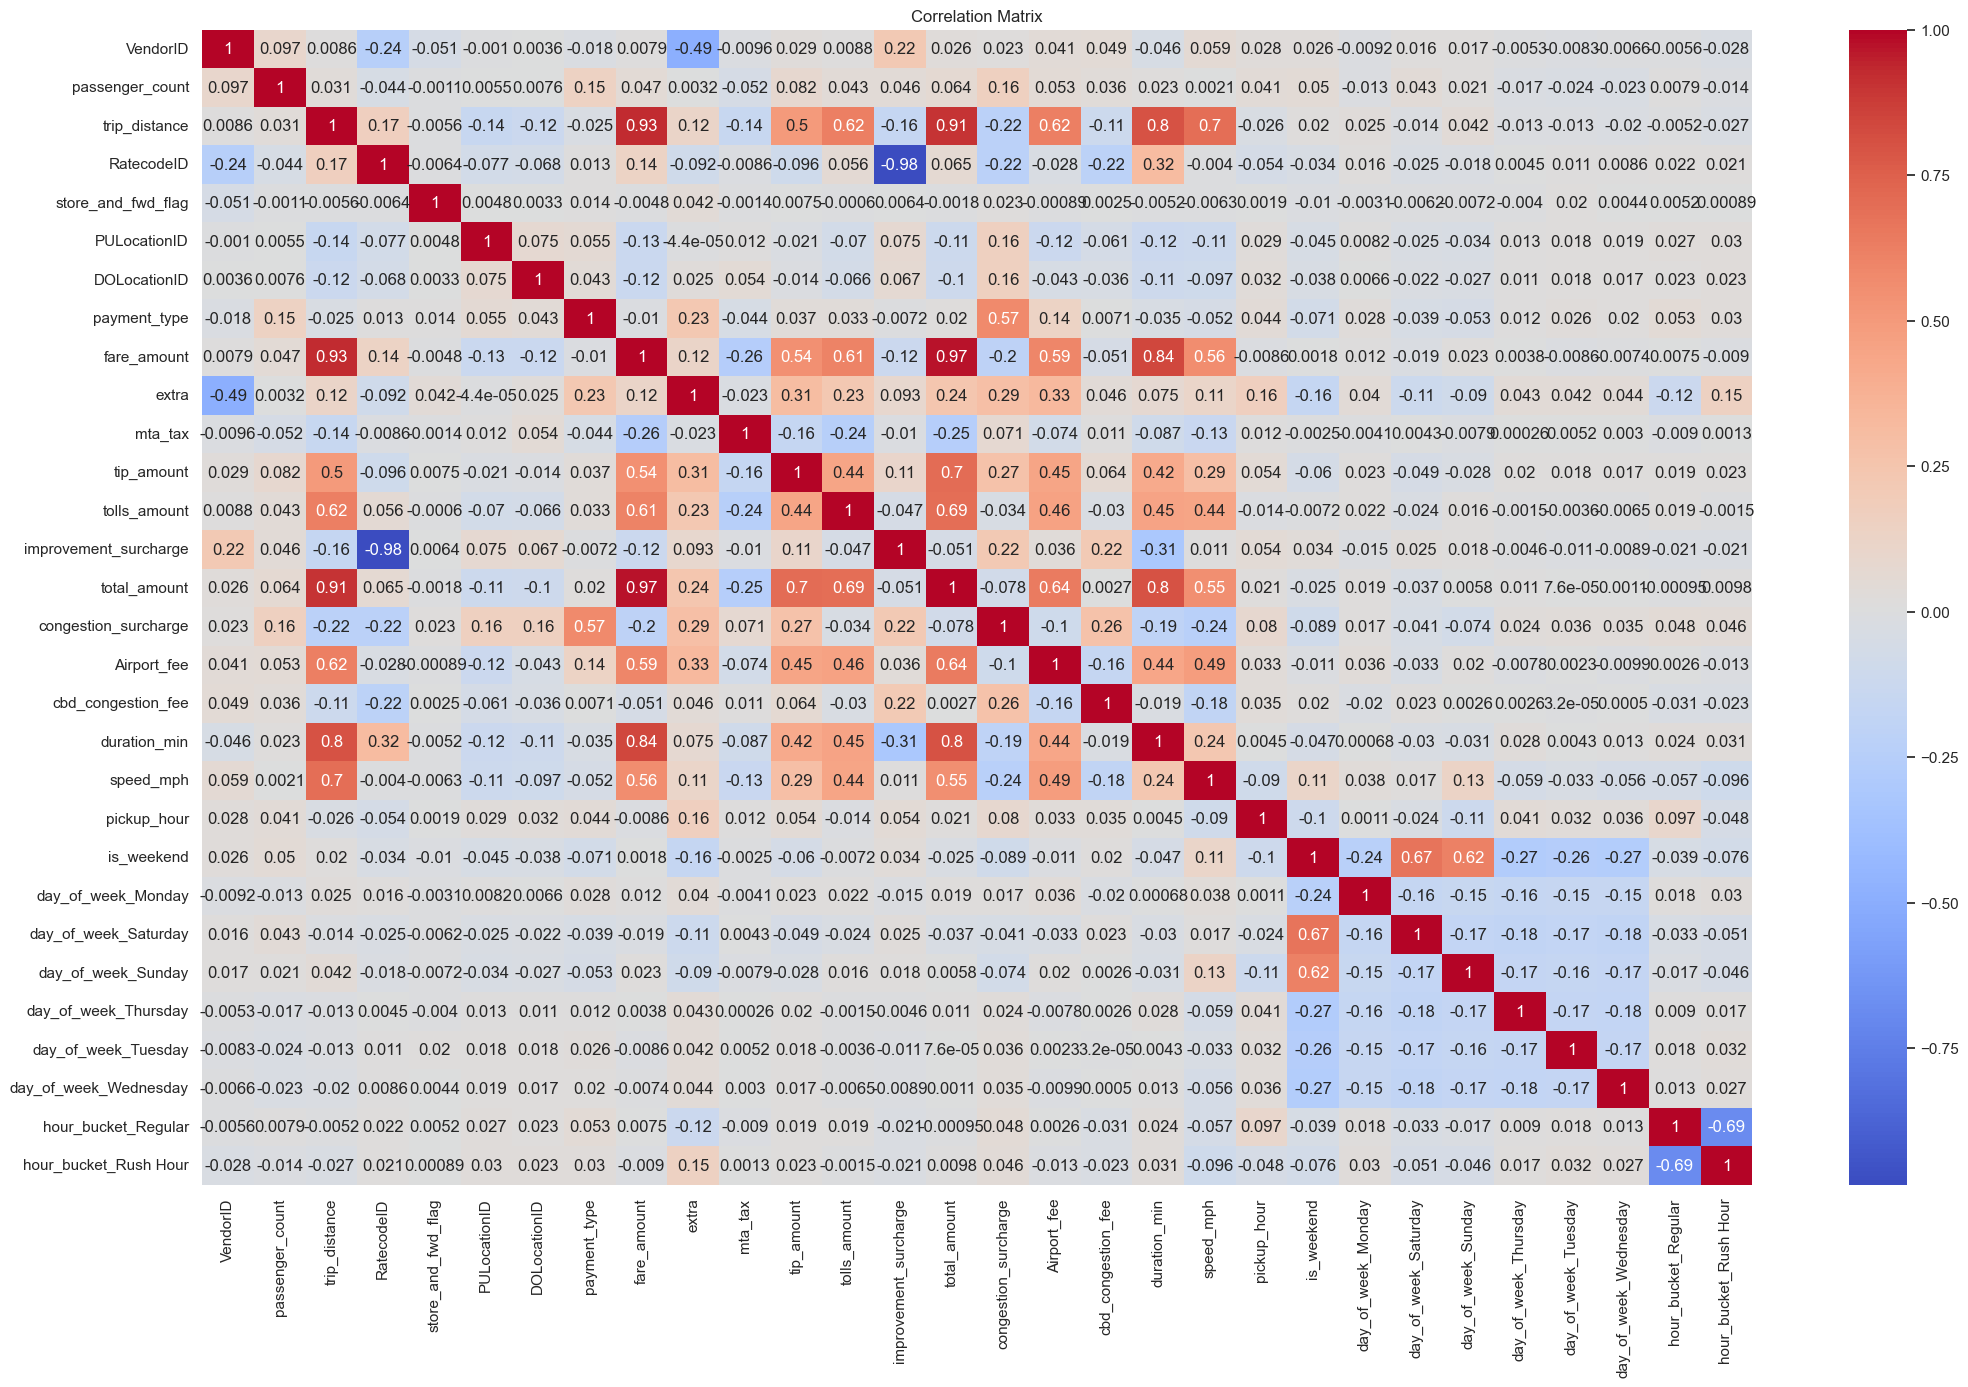

In [28]:
plt.figure(figsize=(25,15))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Train Test Split

In [29]:
# 1. Lakukan sampling terlebih dahulu
df_sample = df_clean.sample(n=200000, random_state=42)

In [30]:
cols_to_drop = [
    'tpep_pickup_datetime', 'tpep_dropoff_datetime',
    'total_amount', 'duration_min', 'speed_mph',
    'fare_amount', 'extra', 'mta_tax', 'tip_amount', 
    'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 
    'Airport_fee', 'cbd_congestion_fee','is_weekend'
]
X= df_sample.drop(columns=cols_to_drop)
y= df_sample[['total_amount','duration_min']]

In [31]:
vif = pd.DataFrame({
    'Feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])]
})

print(vif.sort_values('VIF', ascending=False))

                  Feature        VIF
0                VendorID  13.028748
5            PULocationID   6.553005
8             pickup_hour   6.205484
6            DOLocationID   5.885670
1         passenger_count   4.551883
15    hour_bucket_Regular   3.948514
7            payment_type   3.296056
16  hour_bucket_Rush Hour   2.672239
12   day_of_week_Thursday   1.919769
10   day_of_week_Saturday   1.916499
14  day_of_week_Wednesday   1.900334
13    day_of_week_Tuesday   1.835185
11     day_of_week_Sunday   1.773269
2           trip_distance   1.760461
9      day_of_week_Monday   1.729662
3              RatecodeID   1.115083
4      store_and_fwd_flag   1.005415


In [32]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200000 entries, 1862320 to 1968869
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               200000 non-null  int64  
 1   passenger_count        200000 non-null  int64  
 2   trip_distance          200000 non-null  float64
 3   RatecodeID             200000 non-null  int64  
 4   store_and_fwd_flag     200000 non-null  int64  
 5   PULocationID           200000 non-null  int64  
 6   DOLocationID           200000 non-null  int64  
 7   payment_type           200000 non-null  int64  
 8   pickup_hour            200000 non-null  int64  
 9   day_of_week_Monday     200000 non-null  int64  
 10  day_of_week_Saturday   200000 non-null  int64  
 11  day_of_week_Sunday     200000 non-null  int64  
 12  day_of_week_Thursday   200000 non-null  int64  
 13  day_of_week_Tuesday    200000 non-null  int64  
 14  day_of_week_Wednesday  200000 non-

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train size : {len(X_train):,}')
print(f'Test size  : {len(X_test):,}')

Train size : 160,000
Test size  : 40,000


## Standart Scaled

In [34]:

continues_cols = ['trip_distance','passenger_count','pickup_hour']
continues_cols = [c for c in continues_cols if c in X.columns]
print(continues_cols)

['trip_distance', 'passenger_count', 'pickup_hour']


In [35]:
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

In [36]:

from sklearn.preprocessing import StandardScaler

features_scaler = StandardScaler()
X_train_scaled[continues_cols] = features_scaler.fit_transform(X_train[continues_cols])
X_test_scaled[continues_cols]  = features_scaler.transform(X_test[continues_cols])


In [37]:
import joblib

joblib.dump(features_scaler,'scaler.joblib')

target_scaler= StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train)
y_test_scaled = target_scaler.transform(y_test)

joblib.dump(target_scaler, 'target_scaler.joblib')
print("Target Scaler disimpan sebagai 'target_scaler.joblib'.")

Target Scaler disimpan sebagai 'target_scaler.joblib'.


## Hypertunning


In [39]:
import optuna
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score

def objective(trial):
    model_type = trial.suggest_categorical('model_type',['Ridge','RandomForest','Xgboost'])

    if model_type == 'Ridge':
        alpha = trial.suggest_float('alpha',1e-3,1e2,log=True)
        solver = trial.suggest_categorical('solver',['auto','svd','cholesky','lsqr'])
        model = Ridge(alpha=alpha,solver=solver, random_state=42)
    elif model_type == 'RandomForest':
        n_estimator = trial.suggest_int('rf_n_estimator',50,100)
        max_depth = trial.suggest_int('rf_max_depth',6,12)
        model = RandomForestRegressor(n_estimators=n_estimator, max_depth=max_depth,n_jobs=1,random_state=42)
    else:
        n_estimators = trial.suggest_int('xgb_n_estimator',50,100)
        max_depth = trial.suggest_int('xgb_max_depth',4,8)
        learning_rate = trial.suggest_float('xgb_lr', 0.01, 0.2)
        model = XGBRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,n_jobs=-1,random_state=42
        )
    score = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='r2').mean()
    return score

print("memulai Hypertunning")
study = optuna.create_study(direction='maximize')
study.optimize(objective,n_trials=20)

print("\n Model & Parameter terbaik")
print(f"R2 Score Terbaik: {study.best_value:.4f}")
print("Hasil Parameter")
for key, value in study.best_params.items():
    print(f"  -> {key}: {value}")

[I 2026-06-18 22:11:06,991] A new study created in memory with name: no-name-76dd705e-c48b-45ed-ba64-929274af566d


memulai Hypertunning


[I 2026-06-18 22:11:07,212] Trial 0 finished with value: 0.7630727325397336 and parameters: {'model_type': 'Ridge', 'alpha': 0.032098086214578284, 'solver': 'cholesky'}. Best is trial 0 with value: 0.7630727325397336.
[I 2026-06-18 22:11:09,243] Trial 1 finished with value: 0.8487136165301005 and parameters: {'model_type': 'Xgboost', 'xgb_n_estimator': 84, 'xgb_max_depth': 4, 'xgb_lr': 0.05895929381661961}. Best is trial 1 with value: 0.8487136165301005.
[I 2026-06-18 22:11:11,921] Trial 2 finished with value: 0.8319844007492065 and parameters: {'model_type': 'Xgboost', 'xgb_n_estimator': 64, 'xgb_max_depth': 7, 'xgb_lr': 0.03018795907404906}. Best is trial 1 with value: 0.8487136165301005.
[I 2026-06-18 22:11:59,007] Trial 3 finished with value: 0.8472084518818098 and parameters: {'model_type': 'RandomForest', 'rf_n_estimator': 65, 'rf_max_depth': 11}. Best is trial 1 with value: 0.8487136165301005.
[I 2026-06-18 22:11:59,296] Trial 4 finished with value: 0.762950879318916 and paramet


 Model & Parameter terbaik
R2 Score Terbaik: 0.8769
Hasil Parameter
  -> model_type: Xgboost
  -> xgb_n_estimator: 100
  -> xgb_max_depth: 8
  -> xgb_lr: 0.19551071870623898


## Modeling


### Machine Learning

In [ ]:

from sklearn.metrics import r2_score

# 1. Mengidentifikasi model terbaik hasil Optuna
best_params = study.best_params.copy()
best_model_type = best_params.pop('model_type') # Hapus model_type dari dictionary parameter

print(f"Menginisialisasi model terbaik: {best_model_type}...")

# 2. Membuat instansiasi model pemenang dengan parameternya
if best_model_type == 'Ridge':
    best_model = Ridge(**best_params, random_state=42)
    
elif best_model_type == 'RandomForest':
    # Kembalikan nama parameter asli RandomForest (menghilangkan prefix 'rf_')
    rf_params = {k.replace('rf_', ''): v for k, v in best_params.items()}
    best_model = RandomForestRegressor(**rf_params, n_jobs=-1, random_state=42)
    
else:  # XGBoost
    # Kembalikan nama parameter asli XGBoost (menghilangkan prefix 'xgb_')
    xgb_params = {k.replace('xgb_', ''): v for k, v in best_params.items()}
    # Sesuaikan singkatan 'lr' menjadi 'learning_rate'
    if 'lr' in xgb_params:
        xgb_params['learning_rate'] = xgb_params.pop('lr')
    best_model = XGBRegressor(**xgb_params, n_jobs=-1, random_state=42)

# 3. Latih model terbaik di data latih
best_model.fit(X_train_scaled, y_train)

# 4. Prediksi
y_pred_ml = best_model.predict(X_test_scaled)
y_pred_train=best_model.predict(X_train_scaled)


# 5. Evaluasi
mae_amount_ml = mean_absolute_error(y_test.iloc[:, 0], y_pred_ml[:, 0])
mae_duration_ml = mean_absolute_error(y_test.iloc[:, 1], y_pred_ml[:, 1])
r2_amount_ml = r2_score(y_test.iloc[:, 0], y_pred_ml[:, 0])
r2_duration_ml = r2_score(y_test.iloc[:, 1], y_pred_ml[:, 1])

print("\n--- Hasil Evaluasi Model ML Terbaik (Hasil Tuning) Test ---")
print(f"Model Pilihan        : {best_model_type}")
print(f"Tarif [total_amount]  -> MAE: ${mae_amount_ml:.2f} | R2 Score: {r2_amount_ml:.4f}")
print(f"Durasi [duration_min] -> MAE: {mae_duration_ml:.2f} menit | R2 Score: {r2_duration_ml:.4f}")


mae_amount_train = mean_absolute_error(y_train.iloc[:, 0], y_pred_train[:, 0])
mae_duration_train = mean_absolute_error(y_train.iloc[:, 1], y_pred_train[:, 1])
r2_amount_train = r2_score(y_train.iloc[:, 0], y_pred_train[:, 0])
r2_duration_train = r2_score(y_train.iloc[:, 1], y_pred_train[:, 1])

print("\n--- Hasil Evaluasi Model ML Terbaik (Hasil Tuning) Train ---")
print(f"Model Pilihan        : {best_model_type}")
print(f"Tarif [total_amount]  -> MAE: ${mae_amount_train:.2f} | R2 Score: {r2_amount_train:.4f}")
print(f"Durasi [duration_min] -> MAE: {mae_duration_train:.2f} menit | R2 Score: {r2_duration_train:.4f}")
# 6. Simpan model pemenang untuk deployment
joblib.dump(best_model, 'model_ml_best.joblib')
print(f"\nModel terbaik disimpan sebagai 'model_ml_best.joblib'.")


Menginisialisasi model terbaik: Xgboost...


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:33:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Hasil Evaluasi Model ML Terbaik (Hasil Tuning) ---
Model Pilihan        : Xgboost
Tarif [total_amount]  -> MAE: $3.09 | R2 Score: 0.9337
Durasi [duration_min] -> MAE: 3.49 menit | R2 Score: 0.8246

--- Hasil Evaluasi Model ML Terbaik (Hasil Tuning) ---
Model Pilihan        : Xgboost
Tarif [total_amount]  -> MAE: $2.76 | R2 Score: 0.9542
Durasi [duration_min] -> MAE: 3.15 menit | R2 Score: 0.8714


### Deep Learning

In [44]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# 1. Definisikan Dataset Custom PyTorch
class TaxiDataset(Dataset):
    def __init__(self, X_data, y_data):
        # Konversi data input (Pandas DataFrame) dan target (numpy array) ke PyTorch Tensors
        self.X = torch.tensor(X_data.values, dtype=torch.float32)
        self.y = torch.tensor(y_data, dtype=torch.float32)
        
    def __len__(self):
        return len(self.X)
        
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# 2. Definisikan Arsitektur Neural Network (Multi-Layer Perceptron)
# Model ini menerima sejumlah fitur input dan menghasilkan 2 output secara bersamaan
class TaxiMLP(nn.Module):
    def __init__(self, input_dim):
        super(TaxiMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2), # Mencegah Overfitting
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)  # Output berdimensi 2: [total_amount, duration_min]
        )
        
    def forward(self, x):
        return self.net(x)

# 3. Setup Dataset dan DataLoaders

train_dataset = TaxiDataset(X_train_scaled, y_train_scaled)
test_dataset = TaxiDataset(X_test_scaled, y_test_scaled)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

# 4. Inisialisasi Model, Loss, dan Optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_scaled.shape[1]
model = TaxiMLP(input_dim).to(device)
criterion = nn.MSELoss() # Menggunakan Mean Squared Error sebagai loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 5. Training Loop
epochs = 5
print(f"Melatih model Deep Learning di device: {device} selama {epochs} epochs...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        
        # Backward pass & Optimization
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * X_batch.size(0)
        
    epoch_loss = running_loss / len(train_dataset)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f}")

# 6. Lakukan Prediksi pada Data Uji (Test Set)
model.eval()
y_pred_dl_scaled = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch)
        y_pred_dl_scaled.append(preds.cpu().numpy())

y_pred_dl_scaled = np.vstack(y_pred_dl_scaled)

# 7. Kembalikan Prediksi ke Skala Aslinya Menggunakan target_scaler (Inverse Transform)
y_pred_dl = target_scaler.inverse_transform(y_pred_dl_scaled)

# 8. Hitung Metrik Evaluasi Deep Learning
mae_amount_dl = mean_absolute_error(y_test.iloc[:, 0], y_pred_dl[:, 0])
mae_duration_dl = mean_absolute_error(y_test.iloc[:, 1], y_pred_dl[:, 1])
r2_amount_dl = r2_score(y_test.iloc[:, 0], y_pred_dl[:, 0])
r2_duration_dl = r2_score(y_test.iloc[:, 1], y_pred_dl[:, 1])

print("\n--- Hasil Evaluasi Deep Learning (PyTorch MLP) ---")
print(f"Tarif [total_amount]  -> MAE: ${mae_amount_dl:.2f} | R2 Score: {r2_amount_dl:.4f}")
print(f"Durasi [duration_min] -> MAE: {mae_duration_dl:.2f} menit | R2 Score: {r2_duration_dl:.4f}")

# 9. Simpan Model PyTorch
# torch.save(model.state_dict(), 'model_dl.pth')
# print("\nModel Deep Learning disimpan sebagai 'model_dl.pth'.")


Melatih model Deep Learning di device: cpu selama 5 epochs...
Epoch 1/5 | Loss: 0.6382
Epoch 2/5 | Loss: 0.2683
Epoch 3/5 | Loss: 0.2343
Epoch 4/5 | Loss: 0.2226
Epoch 5/5 | Loss: 0.2148

--- Hasil Evaluasi Deep Learning (PyTorch MLP) ---
Tarif [total_amount]  -> MAE: $4.60 | R2 Score: 0.8697
Durasi [duration_min] -> MAE: 4.50 menit | R2 Score: 0.7345


In [46]:
# 1. Dataset Custom PyTorch (Tetap Sama)
class TaxiDataset(Dataset):
    def __init__(self, X_data, y_data):
        self.X = torch.tensor(X_data.values, dtype=torch.float32)
        self.y = torch.tensor(y_data, dtype=torch.float32)
        
    def __len__(self):
        return len(self.X)
        
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# 2. Arsitektur Jaringan Diperlebar + Ditambah Batch Normalization
class OptimizedTaxiMLP(nn.Module):
    def __init__(self, input_dim):
        super(OptimizedTaxiMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),      # Menstabilkan input ke aktivasi berikutnya
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            
            nn.Linear(64, 2)          # Output: [total_amount, duration_min]
        )
        
    def forward(self, x):
        return self.net(x)

# 3. Setup Dataset & Dataloader
train_dataset = TaxiDataset(X_train_scaled, y_train_scaled)
test_dataset = TaxiDataset(X_test_scaled, y_test_scaled)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

# 4. Inisialisasi Model, Loss, dan Optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_scaled.shape[1]
model = OptimizedTaxiMLP(input_dim).to(device)

# --- OPTIMASI 1: Ganti ke Huber Loss ---
criterion = nn.HuberLoss(delta=1.0) 

# --- OPTIMASI 2: Tambahkan Weight Decay (L2 Regularization) ---
optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5) 

# --- OPTIMASI 3: Tambahkan Learning Rate Scheduler ---
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# 5. Training Loop (Dinaikkan ke 15 Epochs)
epochs = 15
print(f"Melatih model Deep Learning (Optimized) di {device} selama {epochs} epochs...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * X_batch.size(0)
        
    epoch_loss = running_loss / len(train_dataset)
    
    # Update Learning Rate berdasarkan performa loss di epoch tersebut
    scheduler.step(epoch_loss)
    
    print(f"Epoch {epoch+1:02d}/{epochs} | Loss (Huber): {epoch_loss:.5f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

# 6. Lakukan Prediksi
model.eval()
y_pred_dl_scaled = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch)
        y_pred_dl_scaled.append(preds.cpu().numpy())

y_pred_dl_scaled = np.vstack(y_pred_dl_scaled)

# 7. Kembalikan Prediksi ke Skala Asli
y_pred_dl = target_scaler.inverse_transform(y_pred_dl_scaled)

# 8. Hitung Metrik Evaluasi DL
mae_amount_dl = mean_absolute_error(y_test.iloc[:, 0], y_pred_dl[:, 0])
mae_duration_dl = mean_absolute_error(y_test.iloc[:, 1], y_pred_dl[:, 1])
r2_amount_dl = r2_score(y_test.iloc[:, 0], y_pred_dl[:, 0])
r2_duration_dl = r2_score(y_test.iloc[:, 1], y_pred_dl[:, 1])

print("\n--- Hasil Evaluasi Deep Learning (Optimized PyTorch MLP) ---")
print(f"Tarif [total_amount]  -> MAE: ${mae_amount_dl:.2f} | R2 Score: {r2_amount_dl:.4f}")
print(f"Durasi [duration_min] -> MAE: {mae_duration_dl:.2f} menit | R2 Score: {r2_duration_dl:.4f}")

# 9. Simpan Model PyTorch
torch.save(model.state_dict(), 'model_dl.pth')
print("\nModel Deep Learning terbaik berhasil disimpan sebagai 'model_dl.pth'.")


Melatih model Deep Learning (Optimized) di cpu selama 15 epochs...
Epoch 01/15 | Loss (Huber): 0.12440 | LR: 0.005000
Epoch 02/15 | Loss (Huber): 0.09388 | LR: 0.005000
Epoch 03/15 | Loss (Huber): 0.08791 | LR: 0.005000
Epoch 04/15 | Loss (Huber): 0.08518 | LR: 0.005000
Epoch 05/15 | Loss (Huber): 0.08334 | LR: 0.005000
Epoch 06/15 | Loss (Huber): 0.08201 | LR: 0.005000
Epoch 07/15 | Loss (Huber): 0.08167 | LR: 0.005000
Epoch 08/15 | Loss (Huber): 0.08089 | LR: 0.005000
Epoch 09/15 | Loss (Huber): 0.08111 | LR: 0.005000
Epoch 10/15 | Loss (Huber): 0.08025 | LR: 0.005000
Epoch 11/15 | Loss (Huber): 0.07995 | LR: 0.005000
Epoch 12/15 | Loss (Huber): 0.07998 | LR: 0.005000
Epoch 13/15 | Loss (Huber): 0.07949 | LR: 0.005000
Epoch 14/15 | Loss (Huber): 0.07914 | LR: 0.005000
Epoch 15/15 | Loss (Huber): 0.07885 | LR: 0.005000

--- Hasil Evaluasi Deep Learning (Optimized PyTorch MLP) ---
Tarif [total_amount]  -> MAE: $3.98 | R2 Score: 0.9009
Durasi [duration_min] -> MAE: 4.12 menit | R2 Score